# Customer Churn Prediction on Telecommunication company

## 1. Proyect Overview

### Scenario

A telecommunications company which is concerned about the number of customers leaving their land-line business for cable competitors. They need to understand who is more likely to leave the company.

### Objective

The goal of this project is to implement predictive modeling on real-world telecommunication data to identify behavioral patterns that precede service cancellation. This analysis shifts the focus from reactive troubleshooting to proactive retention by:

* Identifying High-Risk Profiles: Accurately predicting which customers are likely to stay and which are showing signs of departure.

* Data-Driven Decision Making: Extracting key data-driven findings to design and implement effective strategies to prevent churn.

## 2. Install and Import libraries


In [ ]:

!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt


%matplotlib inline 

import warnings
warnings.filterwarnings('ignore')

##  3. Load Dataset
Each case corresponds to a separate customer and it records various demographic and service usage information.
This data set provides you information about customer preferences, services opted, personal details, etc. which helps you predict customer churn (1 if the customer left, 0 if they stayed)

In [631]:
file = '/Users/user/Desktop/Data Analysis/Data Science Proyects/Cutomer Churn Prediction Telecomunication/Customer_churn_Tel.csv'
df = pd.read_csv(file)

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


<details>
  <summary> <b>Click to expand: Variable Summary</b></summary>
    <div style="line-height: 1.6; font-family: sans-serif;">
    <p><b>Demographics:</b></p>
    <ul>
        <li> <b>gender</b>: Whether the customer is a male or a female.</li>
        <li> <b>SeniorCitizen</b>: Whether the customer is a senior citizen or not (1, 0).</li>
        <li> <b>Partner</b>: Whether the customer has a partner or not (Yes, No).</li>
        <li> <b>Dependents</b>: Whether the customer has dependents or not (Yes, No).</li>
    </ul>
    
<p><b>Services:</b></p>
    <ul>
        <li> <b>tenure</b>: Number of months the customer has stayed with the company.</li>
        <li> <b>PhoneService</b>: Whether the customer has a phone service or not (Yes, No).</li>
        <li> <b>MultipleLines</b>: Whether the customer has multiple lines or not (Yes, No).</li>
        <li> <b>InternetService</b>: Customer’s internet service provider (DSL, Fiber optic, No).</li>
        <li> <b>OnlineSecurity</b>: Whether the customer has online security or not (Yes, No).</li>
        <li> <b>OnlineBackup</b>: Whether the customer has online backup or not (Yes, No).</li>
        <li> <b>DeviceProtection</b>: Whether the customer has device protection or not (Yes, No).</li>
        <li> <b>TechSupport</b>: Whether the customer has tech support or not (Yes, No).</li>
        <li> <b>StreamingTV</b>: Whether the customer has streaming TV or not (Yes, No).</li>
        <li> <b>StreamingMovies</b>: Whether the customer has streaming movies or not (Yes, No).</li>
    </ul>
    
<p><b>Account & Billing:</b></p>
    <ul>
        <li> <b>Contract</b>: The contract term of the customer (Month-to-month, One year, Two year).</li>
        <li> <b>PaperlessBilling</b>: Whether the customer has paperless billing or not (Yes, No).</li>
        <li> <b>PaymentMethod</b>: The customer’s payment method (Electronic check, Mailed check, Bank transfer, Credit card).</li>
        <li> <b>MonthlyCharges</b>: The amount charged to the customer monthly.</li>
        <li> <b>TotalCharges</b>: The total amount charged to the customer.</li>
    </ul>
    
<p><b>Target:</b></p>
    <ul>
        <li> <b>Churn</b>: Whether the customer left (Yes) or stayed (No).</li>
    </ul>
</div>
</details>

In [633]:
df.shape

(7043, 21)

In this project we analyze 7043 clients

In [634]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Data cleaning

### Standardizing categorical values

In [637]:
df.replace(["No internet service","No phone service"], "No", inplace=True)

### Remove unnecessary values

In [639]:
# CustomerID is a variable that is not useful for modeling the system

if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

In [640]:
# TotalCharges is a variable derived from the following formula:
# TotalCharges = tenure × MonthlyCharges

# Since this variable is a combination of other features, it may introduce redundancy
# or noise in the model. Therefore, we remove it before modeling.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

df = df.drop(columns=["TotalCharges"])

## 5. Exploratory Data Analysis (EDA)

### - Churn distribution

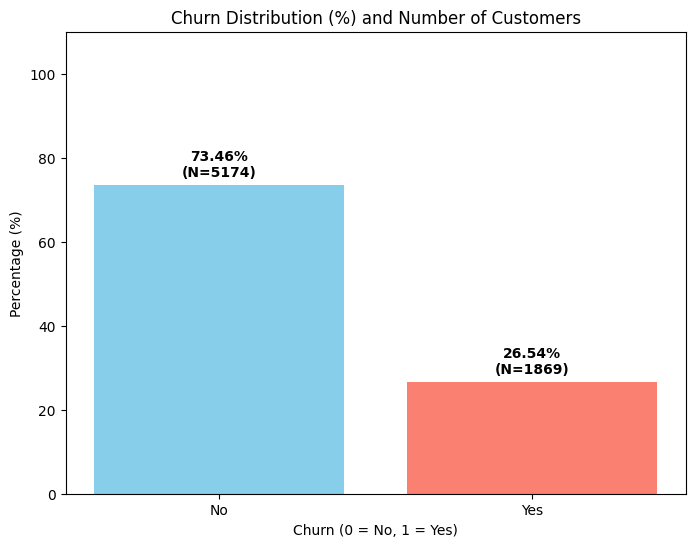

In [643]:
# 1. Calculate both: counts and percentages
counts = df['Churn'].value_counts()
percentages = df['Churn'].value_counts(normalize=True) * 100

# 2. Create the chart
plt.figure(figsize=(8, 6))
bars = plt.bar(percentages.index.astype(str), percentages.values, color=['skyblue', 'salmon'])

plt.title('Churn Distribution (%) and Number of Customers')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Percentage (%)')

# 3. Iterate using the index to obtain both values
for i, (idx, pct) in enumerate(percentages.items()):
    count = counts[idx]  # Get the absolute number
    
    label = f"{pct:.2f}%\n(N={count})"
    
    plt.text(i, pct + 2, label, ha='center', fontweight='bold')

plt.ylim(0, 110)
plt.show()


Although the classes are not perfectly balanced, the imbalance is moderate.

Therefore, the dataset is still suitable for machine learning modeling

### - Monthly Charges

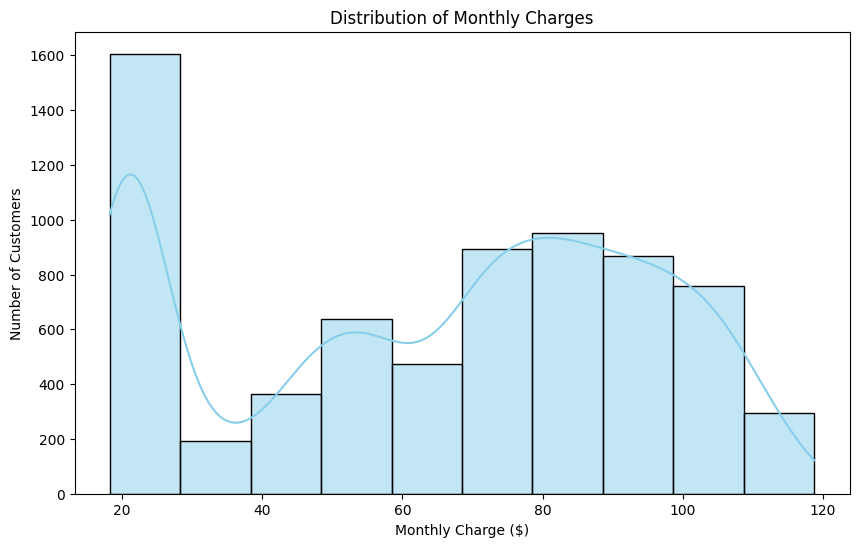

In [646]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyCharges'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charge ($)')
plt.ylabel('Number of Customers')
plt.show()

A significant portion of the customer base pays below $30/month, representing basic service users.

A second concentration is observed between 60 and 110/month

### - KDE Distribution of Monthly Charges

Are customers with higher monthly charges more likely to churn?

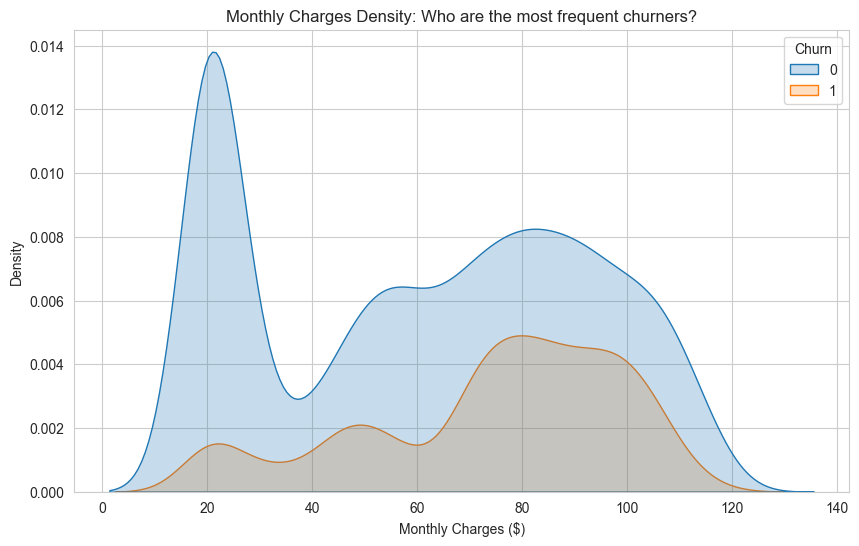

In [753]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.title('Monthly Charges Density: Who are the most frequent churners?')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.show()


* Customers paying around $20/month

These customers typically use basic services (likely only phone service or very basic internet).  
They tend to be very stable because the cost is low, which creates little financial friction.  
Additionally, there may be limited competition offering significantly cheaper alternatives.

* Customers paying around $90/month

This is where the churn curve reaches its highest point.  
This represents a critical customer segment.  
In the telecommunications industry, this price range is often associated with **Fiber Optic internet plans**, suggesting that higher-value services may have a greater churn risk.

### - Tenure Distribution

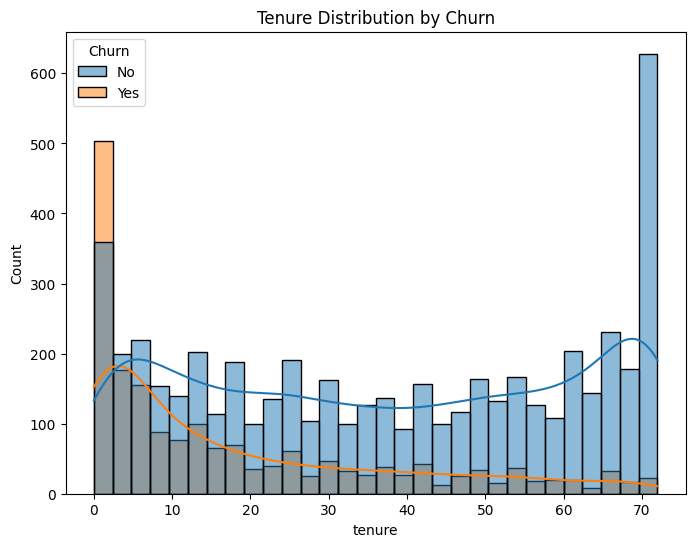

In [653]:
plt.figure(figsize=(8,6))

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)

plt.title("Tenure Distribution by Churn")
plt.show()

It can be clearly observed in the chart that **new customers are more likely to churn**. This will be analyzed in greater detail later in the report.

## 6. Feature Engineering

Based on the previous observations, we create a new variable to improve the modeling process.

This variable identifies **new customers**, defined as those with **less than 12 months of tenure**.  
Since earlier analysis showed that customers with lower tenure are more likely to churn, this feature may help the model better capture that pattern.

In [657]:
df["New Customer"] = (df["tenure"] < 12).astype(int)

Since the dataset contains several categorical variables, we transform them into **binary (0/1) dummy variables** using one-hot encoding.


In [659]:
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

df2 = pd.get_dummies(df, drop_first = True)

df2.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,New Customer,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,0,1,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,0,0,True,False,False,True,False,...,True,False,False,False,True,False,False,False,False,True
2,0,2,53.85,1,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,0,0,True,False,False,False,False,...,True,True,False,False,True,False,False,False,False,False
4,0,2,70.70,1,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 7. Data standardization

In [662]:
cols_continuas = ['tenure', 'MonthlyCharges']

df2[cols_continuas] = StandardScaler().fit_transform(df2[cols_continuas])

df2.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,New Customer,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.277445,-1.160323,0,1,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,0.066327,-0.259629,0,0,True,False,False,True,False,...,True,False,False,False,True,False,False,False,False,True
2,0,-1.236724,-0.362660,1,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0.514251,-0.746535,0,0,True,False,False,False,False,...,True,True,False,False,True,False,False,False,False,False
4,0,-1.236724,0.197365,1,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 8. Modeling

### Splitting the data set

In [665]:
X, y = np.asarray(df2.drop(columns=["Churn"])) , np.asarray(df2["Churn"])

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)

### * Logistic Regression

In [667]:
LR = LogisticRegression(class_weight='balanced').fit(X_train,y_train)

In [668]:
yhat_prob = LR.predict_proba(X_test)
yhat_prob[:10]

array([[0.57451074, 0.42548926],
       [0.53200096, 0.46799904],
       [0.65431395, 0.34568605],
       [0.13218948, 0.86781052],
       [0.12623023, 0.87376977],
       [0.0730821 , 0.9269179 ],
       [0.96459166, 0.03540834],
       [0.96265982, 0.03734018],
       [0.10651781, 0.89348219],
       [0.23461059, 0.76538941]])

#### Model Evaluation



#### Log loss

Once the predictions have been generated, it becomes prudent to evaluate the performance of the model in predicting the target variable.

Log loss (Logarithmic loss), also known as Binary Cross entropy loss, is a function that generates a loss value based on the class wise prediction probabilities and the actual class labels. The lower the log loss value, the better the model is considered to be.


In [671]:
log_loss(y_test, yhat_prob)

0.513001493708271


The model shows a relatively high **log loss**, indicating that the predicted probabilities are not well calibrated.

This may occur because **Logistic Regression assumes a linear relationship between the input features and the target variable**. However, customer churn behavior is often influenced by more complex and non-linear interactions between variables.




### * Random Forest Classifier


We chose this type of model because it performs well with datasets that contain many variables and **non-linear relationships** between features, making them well suited for problems such as customer churn prediction.

In [675]:
# Import libraries for this model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score


In [676]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [677]:
n_estimators=180

rf = RandomForestClassifier(n_estimators=n_estimators, random_state=42, max_depth = 10)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=180, random_state=42)

#### Model Evaluation

In [679]:
y_pred_rf= rf.predict_proba(X_test)
y_pred_rf[:10]


array([[0.35097398, 0.64902602],
       [0.89572412, 0.10427588],
       [0.97599878, 0.02400122],
       [0.23846944, 0.76153056],
       [0.92872175, 0.07127825],
       [0.73249747, 0.26750253],
       [0.96109741, 0.03890259],
       [0.99094083, 0.00905917],
       [0.8047258 , 0.1952742 ],
       [0.69749302, 0.30250698]])

In [680]:
log_loss(y_test, y_pred_rf)

0.4013648473398309

log_loss decrease significativly

### Matrix Confussion

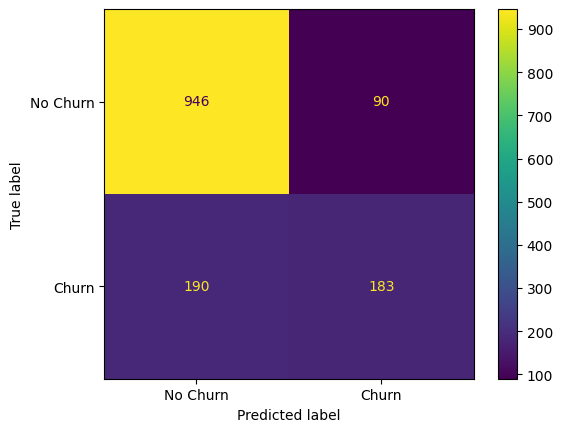

In [683]:
y_pred_rf = rf.predict(X_test)
y_pred_rf[:10]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn","Churn"])
disp.plot()
plt.show()

The model performs very well at identifying customers who will remain with the company.  
It correctly classifies around 91% of non-churn customers.

However, its performance detecting churners is more limited. The model only identifies approximately 50% of the customers who actually leave.

This means that while the model is reliable at confirming customer retention, it still misses a significant portion of churn cases, which are typically the most important to detect in a churn prediction problem.

----------------

By default, classification models use a probability threshold of 0.5 to assign classes.  
However, in churn prediction problems, detecting potential churners is often more valuable than minimizing false positives.

To improve churn detection, the decision threshold was lowered to 0.35. This allows the model to identify more at-risk customers, at the cost of slightly increasing false positives.

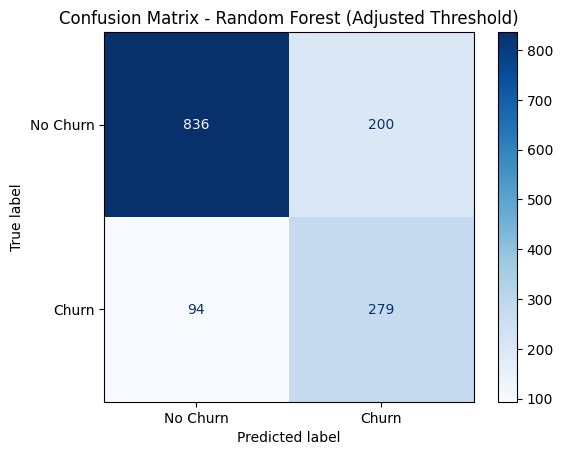

In [687]:
threshold = 0.35
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_pred_adjusted = (y_prob_rf >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_adjusted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn","Churn"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest (Adjusted Threshold)")
plt.show()

After lowering the classification threshold to 0.35, the model significantly improved its ability to detect churners.

The recall for churn increased from approximately 49% to 74.8%. This means the model is now able to identify a much larger proportion of customers at risk of leaving.


## 9) Feature importance

We analyze the importance of each feature in the model to understand how much influence each variable has on predicting **customer churn**.

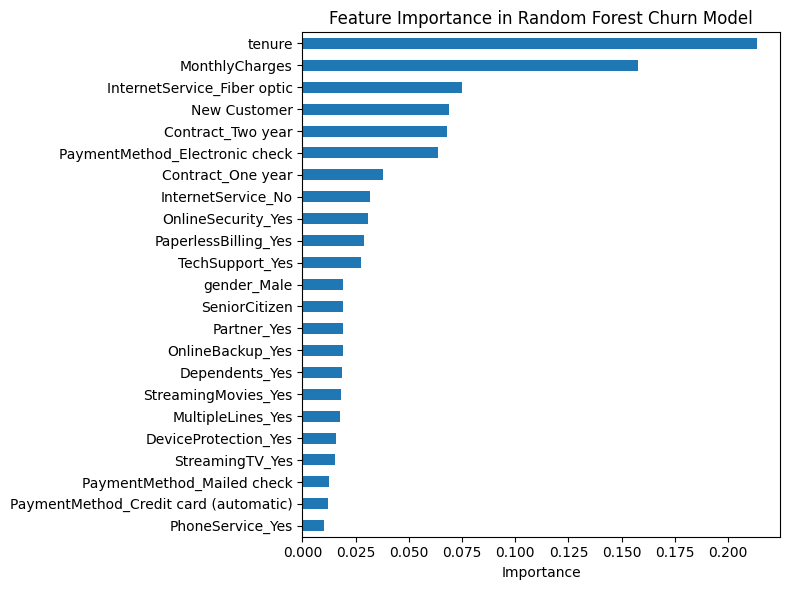

In [691]:
feature_names= df2.drop(columns=['Churn']).columns   

importances = pd.Series(rf.feature_importances_, index=feature_names)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance in Random Forest Churn Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 10. Deep Analysis of Key Variables

Based on the feature importance results, we will focus our analysis on the **most important variables**.

A deeper analysis of these features will be conducted in order to extract meaningful insights and identify potential actions that could help reduce customer churn.

### - Tenure analysis

Since "tenure" is the most significant variable in the Random Forest modeling, we analyze its importance regarding churn and extract insights to support decision-making.

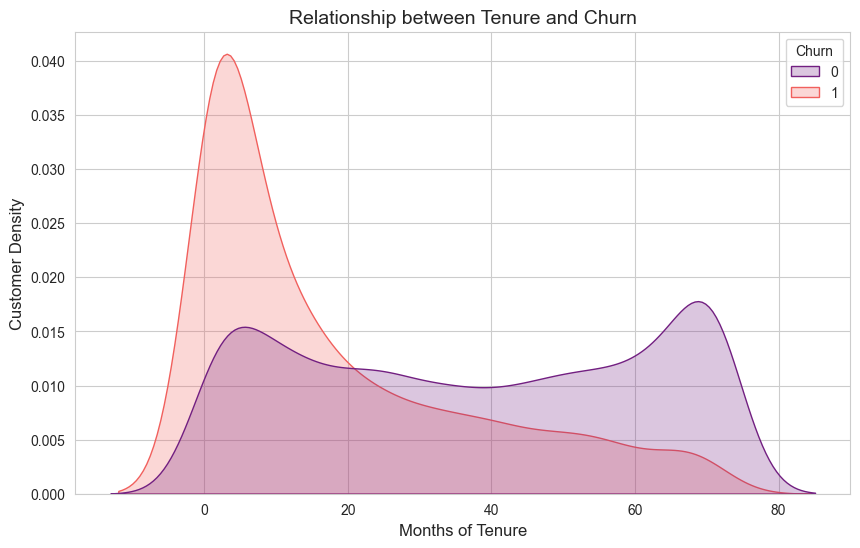

In [775]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='magma', common_norm=False)

plt.title('Relationship between Tenure and Churn', fontsize=14)
plt.xlabel('Months of Tenure', fontsize=12)
plt.ylabel('Customer Density', fontsize=12)

# If the plot still doesn't show, plt.draw() can sometimes force it
plt.show()

* It can be observed that if a customer stays longer than two years, they are more likely to remain with the company. This trend is more clearly visualized in the following boxplot:

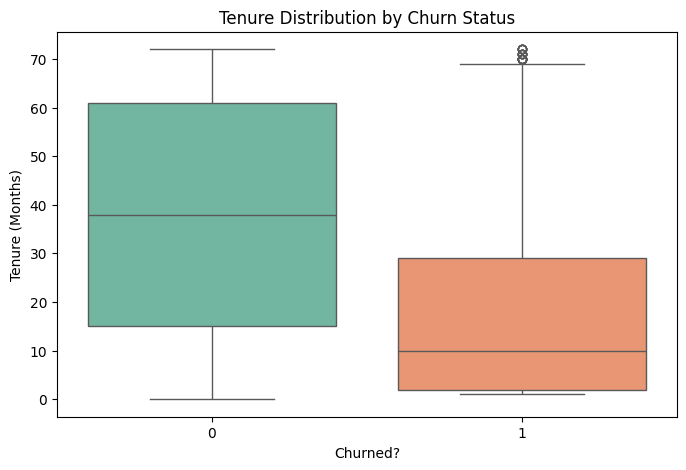

In [707]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churned?')
plt.ylabel('Tenure (Months)')
plt.show()

* We can conclude that greater attention must be directed toward new customers by maintaining more frequent contact and proactively addressing their needs. Surveys are essential for monitoring the quality of service provided and identifying specific areas for improvement. Implementing Satisfaction Surveys (NPS) at the 3 and 6-month marks serves as a brilliant preventive tool to mitigate early-stage churn.

    Another proposal is to offer a promotional discount for the first 6 months of service. This incentivizes retention during the most critical period of the customer lifecycle.

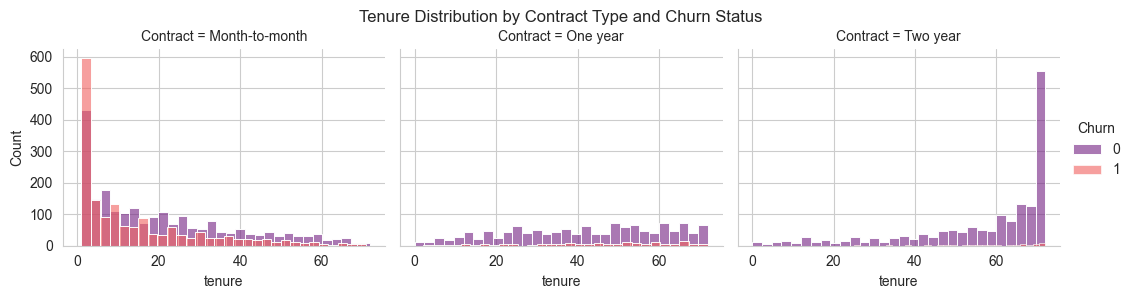

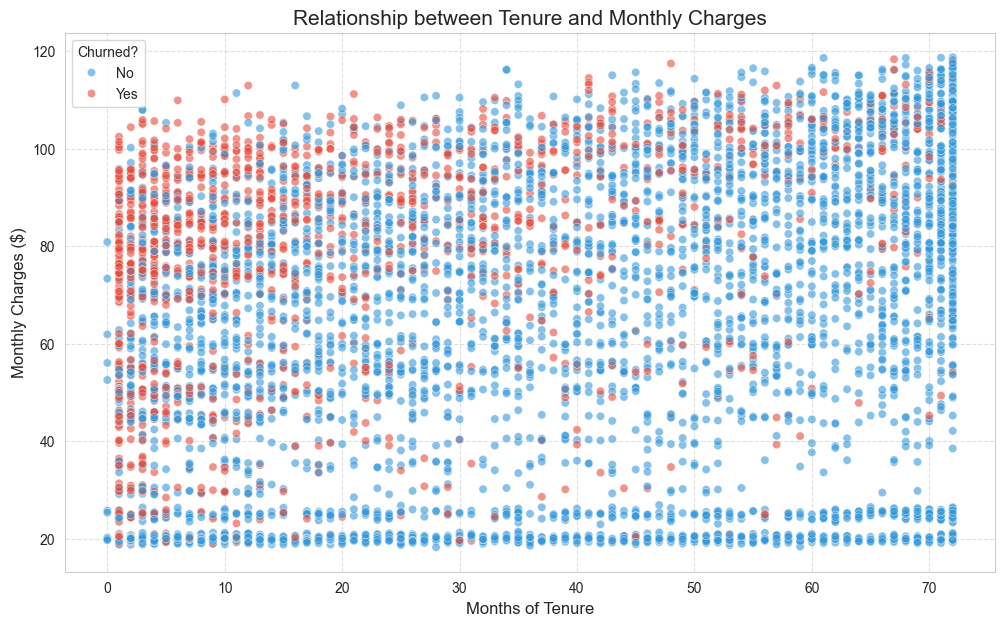

In [936]:

sns.set_style("whitegrid")
g = sns.FacetGrid(df, col="Contract", hue="Churn", height=3, aspect=1.2, palette='magma')
g.map(sns.histplot, "tenure", bins=30, alpha=0.6)
g.add_legend()

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Tenure Distribution by Contract Type and Churn Status')
plt.show()

#-------------------------------

df_plot = df.copy()
df_plot['Churn'] = df_plot['Churn'].map({1: 'Yes', 0: 'No'})

plt.figure(figsize=(12, 7))


sns.scatterplot(data=df_plot, x='tenure', y='MonthlyCharges', hue='Churn', 
                alpha=0.6, palette=['#3498db', '#e74c3c'])

plt.title('Relationship between Tenure and Monthly Charges', fontsize=15)
plt.xlabel('Months of Tenure', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.legend(title='Churned?')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#### Chart Observations
*   The tenure data suggests that customers become increasingly valuable over time. The company could propose automatic discounts or loyalty benefits (such as extra data or free premium services) upon reaching their 12th month. This incentivizes them to reach the "safe zone" of long-term retention.

*   The 70 USD  Threshold: Regardless of tenure, there is a high probability of churn for monthly charges above approximately 70 USD. Customers with higher bills are significantly more likely to leave.

* Low-Cost Stability: Customers paying up to $30 tend to remain over time. These are more loyal customers who are not affected by price points, likely because they do not have fiber optics or high-speed internet services.

* The 5-Year Loyalty Peak: Starting around Month 60 (5 years of service), the probability of churn drops drastically. At this stage, customers remain loyal regardless of the amount they are charged.

### - Customers with Paperless Billing

In this section, we examine how digital adoption affects different age demographics.

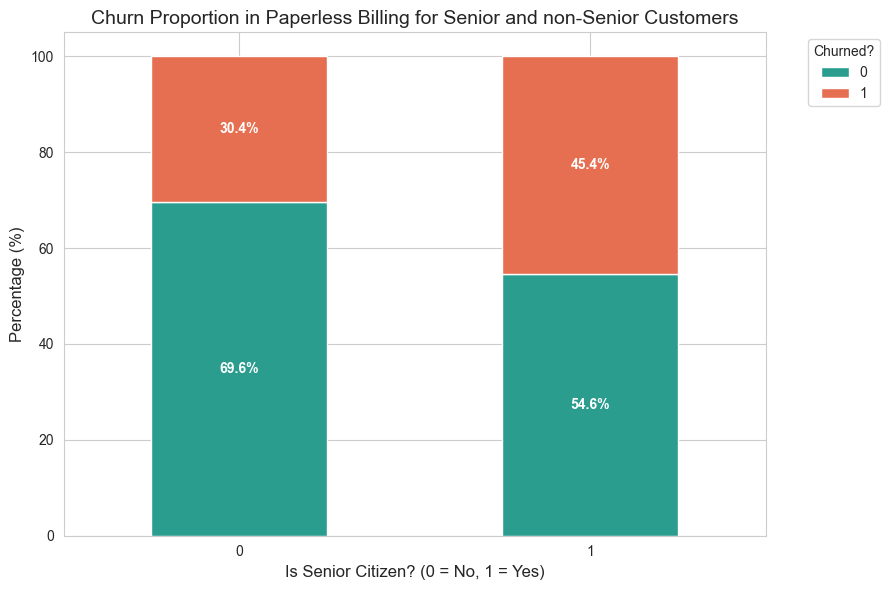

In [916]:
# 1. Calculate rates
df_paperless = df[df['PaperlessBilling'] == 'Yes']
counts = df_paperless.groupby(['SeniorCitizen', 'Churn']).size().unstack()
proportions = counts.divide(counts.sum(axis=1), axis=0) * 100

# 2. Create the graph
ax = proportions.plot(kind='bar', stacked=True, figsize=(9, 6), color=['#2a9d8f', '#e76f51'], rot=0)

plt.title('Churn Proportion in Paperless Billing for Senior and non-Senior Customers', fontsize=14)
plt.xlabel('Is Senior Citizen? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Churned?', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (x + width/2, y + height/2), 
                    ha='center', va='center', 
                    color='white', fontweight='bold')

plt.tight_layout()
plt.show()

* When enrolled in paperless billing, Senior citizens exhibit a significantly higher churn rate compared to the younger population. This suggests that digital-only communication is a high-risk factor for this demographic, likely due to friction in digital accessibility or a preference for physical records.

### - Customers with Monthly Charges above $70 and Fiber Optic Service


Customers with monthly charges exceeding 70 USD are closely associated with the use of fiber optic services. In the following analysis, we will examine this relationship and its direct influence on churn rates. Also 

In this specific segment, 41.12% of customers are leaving.


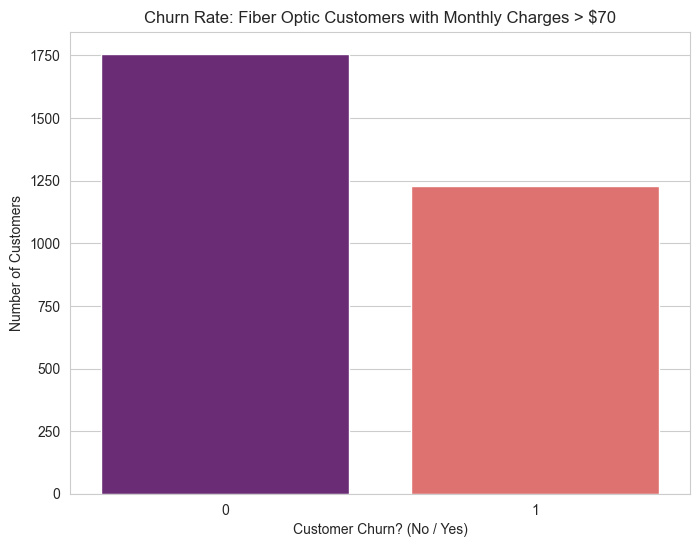

Churn Rate for customers WITHOUT Tech Support: 48.50%
Churn Rate for customers WITH Tech Support: 22.63%


In [941]:
# 1. Filter the data: Customers paying more than 70 with Fiber Optic service
risk_segment = df[(df['MonthlyCharges'] > 70) & (df['InternetService'] == 'Fiber optic')]

# 2. Create the bar chart
plt.figure(figsize=(8,6))
sns.countplot(data=risk_segment, x='Churn', hue='Churn', palette='magma', legend=False)

# 3. Customization for clear impact visualization
plt.title('Churn Rate: Fiber Optic Customers with Monthly Charges > $70')
plt.xlabel('Customer Churn? (No / Yes)')
plt.ylabel('Number of Customers')

# Calculate percentage for conclusion
total = len(risk_segment)
churn_yes = len(risk_segment[risk_segment['Churn'] == 1]) 
churn_percentage = (churn_yes / total) * 100

print(f"In this specific segment, {churn_percentage:.2f}% of customers are leaving.")

plt.show()

#------------------------------------------------------------------------------
# Code to calculate Churn Rate for customers with and without Tech Support

# Formula to calculate the standardized value (Z-score) for $70 (Monthly Charge)
mean = 64
std = 30
z = (70 - mean) / std

# Segment 1: Fiber, High Cost, WITHOUT Tech Support
no_support = df2[(df2['MonthlyCharges'] > z) &   
                  (df2['InternetService_Fiber optic'] == 1) & 
                  (df2['TechSupport_Yes'] == 0)]

# Segment 2: Fiber, High Cost, WITH Tech Support
with_support = df2[(df2['MonthlyCharges'] > z) & 
                    (df2['InternetService_Fiber optic'] == 1) & 
                    (df2['TechSupport_Yes'] == 1)]

print(f"Churn Rate for customers WITHOUT Tech Support: {(no_support['Churn'].mean() * 100):.2f}%")
print(f"Churn Rate for customers WITH Tech Support: {(with_support['Churn'].mean() * 100):.2f}%")

* The data reveals that a significant percentage (41%) of customers leave the company when they pay high monthly rates (above 70) associated with Fiber Optic service. This trend could be attributed to slow service speeds or technical issues resulting in a poor user experience. Additionally, the high costs of Fiber Optic may be perceived as overpriced, leading customers to cancel their subscriptions and seek more affordable competitors.

    Comparing the churn count for this specific segment (1,250) against the total churn in our dataset (1,869), we can observe that it represents 67% of all churn cases. Consequently, addressing the issues within this segment should be the highest priority for the company's retention strategy.

* The data reveals a critical disparity: the churn rate for Fiber Optic customers with monthly charges above 70 USD who lack technical support is approximately 50%. In stark contrast, this rate drops to 22% for those who do have technical support.
  
    Instead of implementing price reductions, the proposed strategy is to provide complimentary Technical Support to all Fiber Optic customers. This value-added service aims to enhance the customer experience and significantly reduce the Churn rate within this high-value segment

### - Month-to-month contract customers paying above $70 with Fiber Optic Service


In this section, we analyze customers on Month-to-Month contracts who pay over 70 USD with iber Optic service. These users represent our most volatile segment. The following visualization examines the tenure distribution within this specific group to identify how quickly these high-value customers are leaving the company.

In [838]:
print('Percentage of Churn for each Contract Category:')

# 1. Month-to-Month Customers (Where the other two contract columns are 0)
month_to_month = df2[(df2['Contract_One year'] == 0) & (df2['Contract_Two year'] == 0)]
print(f"* Month-to-Month Churn: {month_to_month['Churn'].mean()*100:.2f}%")

# 2. One-Year Contract Customers
one_year = df2[df2['Contract_One year'] == 1]
print(f"* One-Year Churn: {one_year['Churn'].mean()*100:.2f}%")

# 3. Two-Year Contract Customers
two_year = df2[df2['Contract_Two year'] == 1]
print(f"* Two-Year Churn: {two_year['Churn'].mean()*100:.2f}%")

Percentage of Churn for each Contract Category:
* Month-to-Month Churn: 42.71%
* One-Year Churn: 11.27%
* Two-Year Churn: 2.83%


As we could expected, customers with month-to-month contract are more likely to end up the service

In this high-risk segment, 54.14% of customers are leaving.


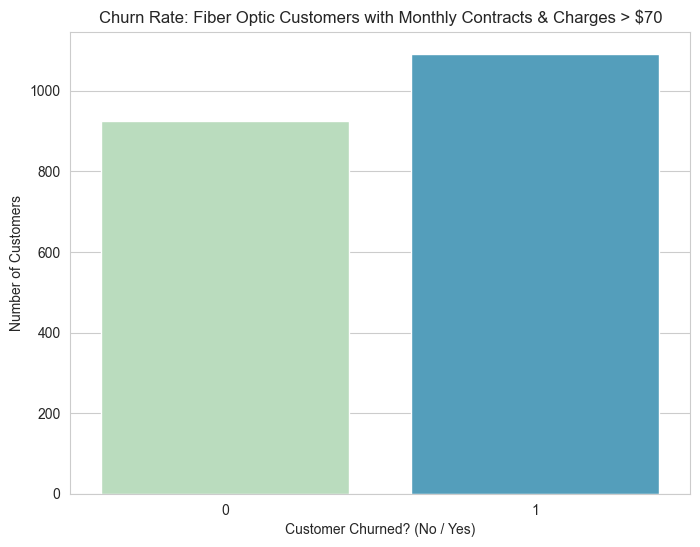

In [763]:
# 1. Filter the data: Month-to-month customers paying > $70 with Fiber Optic
risk_segment = df[(df['MonthlyCharges'] > 70) & 
                  (df['InternetService'] == 'Fiber optic') & 
                  (df['Contract'] == 'Month-to-month')]

# 2. Create the bar chart
plt.figure(figsize=(8,6))
sns.countplot(data=risk_segment, x='Churn', palette='GnBu')

# 3. Customization for clear impact visualization
plt.title('Churn Rate: Fiber Optic Customers with Monthly Contracts & Charges > $70')
plt.xlabel('Customer Churned? (No / Yes)')
plt.ylabel('Number of Customers')

# Calculate the percentage for the conclusion
total = len(risk_segment)
churn_yes = len(risk_segment[risk_segment['Churn'] == 1])
percentage = (churn_yes / total) * 100

print(f"In this high-risk segment, {percentage:.2f}% of customers are leaving.")

plt.show()

* These findings are critical because we have identified that a vast majority of customer churn is concentrated within this specific segment: Customers paying above \$70/month, month-to-month type of contract and Fiber Optic service.

    Instead of offering annual contracts to the entire customer base (which is costly and inefficient), the recommendation is to use the predictive model to isolate only those in the "Fiber + Month-to-Month" group. By offering them a targeted discount to switch to a one-year plan, the company can address the primary source of churn with surgical precision.

## 11. Business Insights

The following insights translate our predictive analysis into actionable business outcomes:

1) We have developed a predictive machine learning model to identify at-risk customers. The confusion matrix confirms high precision in detecting potential churners, allowing for proactive retention actions. The model successfully detects 75% of customers who are actually planning to leave, allowing the company to take proactive retention measures before the loss occurs.

3) Early-stage customers show the highest churn risk. We propose implementing NPS surveys at months 3 and 6 to identify friction points. Additionally, a 6-month introductory discount will bridge the gap until the 'loyalty peak' at year 5.

4) Offer complimentary physical billing to Senior Citizens currently on Paperless plans to mitigate the 45% churn rate. Eliminating digital friction for this segment is a low-cost intervention that protects high-lifetime-value customers.

5) With 67% of churned customers coming from the Fiber Optic segment, service stability is paramount. We must prioritize infrastructure audits and technical maintenance to ensure that the premium price is justified by premium performance.

7) Since 50% of Fiber Optic customers lack technical support, we recommend bundling complimentary Tech Support instead of reducing prices. This adds value to the high-tier segment and directly addresses a known churn driver.
   
9) To stabilize the most volatile segment (Fiber + Month-to-month), we propose a targeted conversion campaign. Offering incentives to switch to 1 or 2-year plans will create a structural barrier against attrition.

### **Autor**

Andres Perucca